In [133]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import (
    Any,
    List, 
    Union, 
    Optional, 
    Callable, 
    Sequence, 
    Literal
)
from transformers import (
    EsmForMaskedLM, 
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch.distributions.categorical import Categorical
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt
import plotly.express as px

from jaxtyping import Bool, Float, Int

from plotly_utils import (
    imshow,
    line
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions
import tempfile
from dataclasses import dataclass

from jumprelu_SAE import ToySAEConfig, JumpReLUToySAE, cycle

In [4]:
MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
FOLD_IDS_TO_USE = [0]
TARGET_FOLD_ID = 0
OUTPUT_PREFIX = "inference_results"
model_name = "facebook/esm2_t33_650M_UR50D"

device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

# Model

In [5]:
def download_hf_checkpoints(repo_id, fold_ids):
    """
    Download specified fold checkpoint files from Hugging Face
    Hugging Faceから指定されたfoldのckptファイルをダウンロード
    
    Note: The model repository is public, so no token is required.
    注意：モデルリポジトリは公開されているため、トークンは不要です。
    """
    print(f"Downloading checkpoints from {repo_id} for folds: {fold_ids}")
    model_paths = []
    temp_dir = tempfile.mkdtemp()
    
    try:
        for fold_id in fold_ids:
            filename = f"covfit_model_20231102_{fold_id}.ckpt"
            print(f"Downloading {filename}...")
            
            # Download (no token needed for public repository)
            # ダウンロード（公開リポジトリのためトークン不要）
            downloaded_path = hf_hub_download(
                repo_id=repo_id,
                filename=filename,
                cache_dir=temp_dir
            )
            model_paths.append(downloaded_path)
            
        print(f"Successfully downloaded {len(model_paths)} checkpoint files")
        return model_paths, temp_dir
        
    except Exception as e:
        # Clean up temporary directory on failure
        # 失敗時はテンポラリディレクトリをクリーンアップ
        shutil.rmtree(temp_dir, ignore_errors=True)
        raise e

In [6]:
model_paths, temp_dir = download_hf_checkpoints(
    repo_id=MODEL_PATH,
    fold_ids=FOLD_IDS_TO_USE
)

task_dict_path = hf_hub_download(
    repo_id=MODEL_PATH,
    filename="task_id_dict.pt"
)

checkpoint = torch.load(model_paths[0], map_location=device)
final_weights = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint

original_task_id_infos = torch.load(task_dict_path, map_location=device)
n_targets_original = len(original_task_id_infos)

model_config = ModelConfig()
model_config.da_model_name = model_name

model = load_model_for_inference(model_paths[0], model_config, n_targets_original)
esm_fine_tuned = model.merge_and_unload() #merge PEFT adapter model with the base model and make a fully new model, see https://stackoverflow.com/questions/77596271/i-want-to-merge-my-peft-adapter-model-with-the-base-model-and-make-a-fully-new-m

# dumb thing to make hooked esm and this esm agree
esm_fine_tuned.esm.embeddings.token_dropout = False

# clean up after installing
if temp_dir and os.path.exists(temp_dir):
    shutil.rmtree(temp_dir, ignore_errors=True)
    print("Temporary files cleaned up")

covfit_model_20231102_0.ckpt:   0%|          | 0.00/2.64G [00:00<?, ?B/s]

Successfully downloaded 1 checkpoint files
Temporary files cleaned up


In [7]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [8]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name

REPO_ID = esm_config.model_name
special_tokens_map_file = "special_tokens_map.json"
tokenizer_config = {}
tokenizer_config["vocab_file"] = hf_hub_download(repo_id=REPO_ID, filename="vocab.txt")
tokenizer_config["model_max_length"] = CONTEXT_LEN
with open(hf_hub_download(repo_id=REPO_ID, filename=special_tokens_map_file), "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [9]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}

In [10]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [11]:
# clean up memory
del model

# Data 

In [12]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [13]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [14]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [15]:
uniq_seqs = []
for suff in pathogen_suffixes:
    fasta_file = f"../../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    uniq_seqs_suff, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences 
    uniq_seqs.extend(uniq_seqs_suff)

In [16]:
# identical code to how it's compute_node_embeddings.py
cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming

tok_output = tokenizer(cut_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)


print(pathogen_name)
print(f"Number unique sequences: {len(cut_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4382
torch.Size([4382, 1024])


In [17]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [18]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [19]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [20]:
batch_len = 200
num_data = tok_seqs.size(0)
dim_mlp = esm_fine_tuned.regressor[0].weight.size(0)

# all output
output_logits = torch.zeros(num_data, d_out_vocab).to(device)

# data for SAE
sae_data_activations = torch.zeros(num_data, dim_mlp).to(device)

for i in tqdm(range(0,num_data,batch_len)):
    esm_output = hooked_esm(tok_seqs[i:i+batch_len])
    
    batch_output = get_logit_hooked(esm_output, list(range(d_out_vocab)))
    # apply linear and ReLU() of esm_regressor to get activations
    batch_activations = esm_fine_tuned.regressor[1](esm_fine_tuned.regressor[0](esm_output[:,0,:]))
    
    output_logits[i:i+batch_len] = batch_output
    sae_data_activations[i:i+batch_len] = batch_activations
    torch.cuda.empty_cache()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [04:32<00:00, 12.37s/it]


In [21]:
logit_id = original_task_id_infos["fitness_USA"]
# logit_id = original_task_id_infos["fitness_South Korea"]

In [22]:
topk = 40
high_fitness_dset_indices = output_logits[:,logit_id].topk(topk, largest=True).indices
low_fitness_dset_indices = output_logits[:,logit_id].topk(topk, largest=False).indices[list(range(topk-1,-1,-1))]

high_toks = tok_seqs[high_fitness_dset_indices, :]
low_toks = tok_seqs[low_fitness_dset_indices, :]
fitness_dset = torch.cat([low_toks, high_toks], dim=0)

In [23]:
high_logit_mean = get_logit_hooked(hooked_esm(high_toks), logit_id).mean().item()
low_logit_mean = get_logit_hooked(hooked_esm(low_toks), logit_id).mean().item()
print(high_logit_mean - low_logit_mean)
torch.cuda.empty_cache()

0.06459099054336548


In [24]:
# high_fitness_esm_out = hooked_esm(high_toks)
# torch.cuda.empty_cache()
# low_fitness_esm_out = hooked_esm(low_toks)
# torch.cuda.empty_cache()

# high_fitness_acts = esm_fine_tuned.regressor[1](esm_fine_tuned.regressor[0](high_fitness_esm_out)) 

# (Jump-ReLU) SAE
### SAE is used in dictionary learning -- Given our dataset $\{x_n\}_{n=1}^N$, we learn an encoder $f:X^m\to X^M$ and decoder $W = [d_1,... d_D]\, s.t.\, x_i\approx\sum_{j=1}^M f_j(x_i) * d_j$
### These $d_j$ represent features in our original space (of dimension $dim_{MLP}$) and by taking the dot product of these vectors with our $W_U[:,\text{logit\_id}]$, we can figure out which features the model believes are correlated with high and low fitness respectively. 
### Then, we can analyze the sequences in our dataset that have the largest activations for the coefficient of these features (Find the $x_i$ which causes $f_j(x_i)$ to have the largest values) and use that to figure out what these features can refer to
### Effectively, what this enables us to do is make a (somewhat justified) claim about what regressor MLP layer is doing when it's trying to predict fitness

## Training SAE (multiplying dataset by constant so that bias does not take over)

In [25]:
torch.autograd.grad_mode.set_grad_enabled(True)
MAGNIFICATION_SIZE = 1e2 # multiply data by constant factor to ensure stable training

In [26]:
d_in = sae_data_activations.size(1)
d_sae = d_in * 32
sae_train_dataset = torch.utils.data.DataLoader(sae_data_activations * MAGNIFICATION_SIZE, batch_size=200, shuffle=False)
# print(d_sae)
# print(d_in)
# print(sae_data_activations.shape)

In [27]:
data = cycle(sae_train_dataset)
def generate_batch() -> Float[Tensor, "batch inst d_in"]:
    """
    Generates a batch of hidden activations from our model.
    """
    return einops.repeat(next(data), "batch d_in -> batch inst d_in", inst=1)

In [28]:
jumprelu_sae = JumpReLUToySAE(
    cfg=ToySAEConfig(
        n_inst=1, # used to train multiple models at once -- unnecessary at this time, so n_inst=1
        d_in=d_in, 
        d_sae=d_sae, 
        tied_weights=True, 
        sparsity_coeff=0.1,
    ),
    # pre_set_bias=sae_data_activations.mean(dim=0)
    pre_set_bias=None
)

In [29]:
# Train SAE
# jumprelu_data_log = jumprelu_sae.optimize(
#     steps=2_000,
#     resample_method="advanced",
#     lr_scale=linear_lr,
#     lr=1e-3,
#     generate_batch=generate_batch
# )  # batch_size=4096?

# Saving/Loading pre-trained SAE 

In [30]:
# # saving
# with open("../../data/covfit_model/jumprelu_sae_save_02_16_25.pkl", "wb") as file:
#     pickle.dump((jumprelu_sae, jumprelu_data_log), file)

# loading
with open("../../data/covfit_model/jumprelu_sae_save_02_16_25.pkl", "rb") as file:
    jumprelu_sae, jumprelu_data_log = pickle.load(file)

# Visualizing SAE training

In [31]:
print(jumprelu_data_log[0].keys())

dict_keys(['steps', 'frac_active', 'loss', 'h', 'h_r', 'b_dec', 'b_enc', 'W_enc', 'log_theta', 'L_reconstruction', 'L_sparsity'])


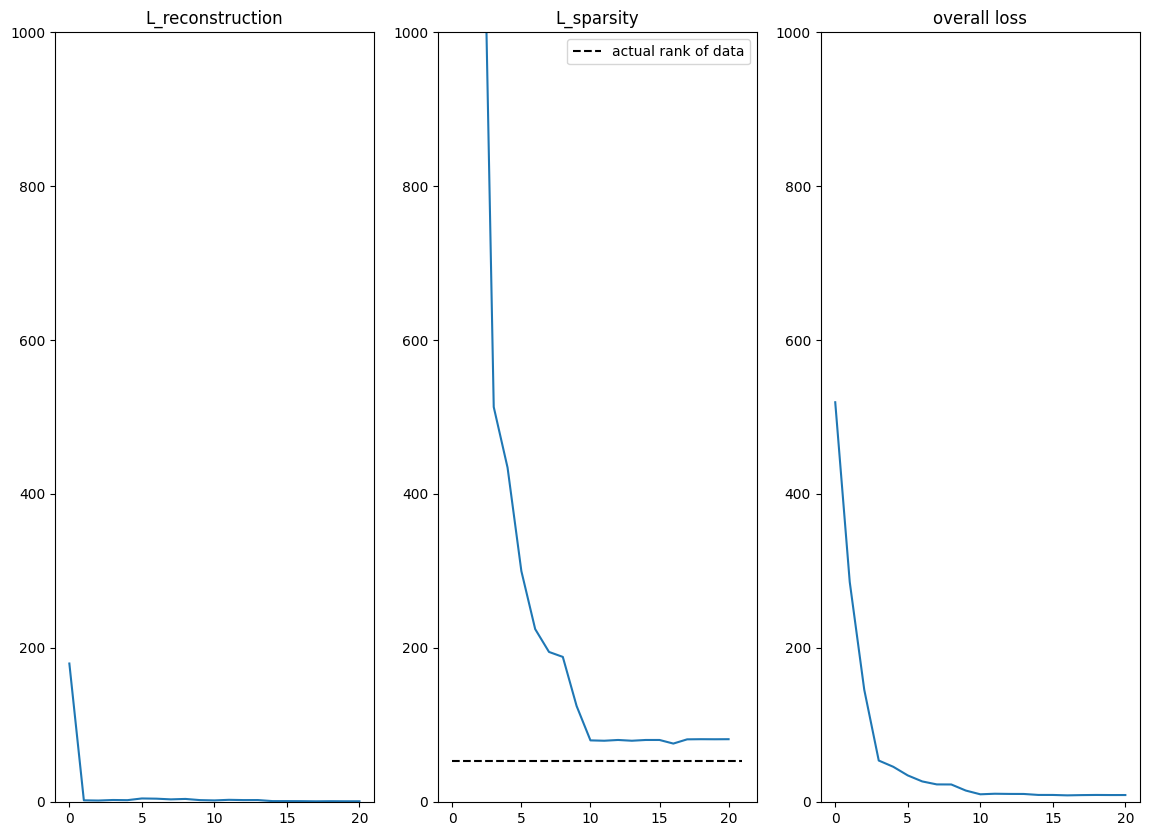

In [32]:
data_rank = torch.linalg.matrix_rank(sae_data_activations).item()

fig, ax = plt.subplots(1,3,figsize=(14,10))
ax[0].plot(list(range(len(jumprelu_data_log))), [d["L_reconstruction"].mean(dim=0) for d in jumprelu_data_log])
ax[0].set_ylim([-1,1e3])
ax[0].set_title("L_reconstruction")

ax[1].plot(list(range(len(jumprelu_data_log))), [d["L_sparsity"].mean(dim=0) for d in jumprelu_data_log])
ax[1].plot([0,len(jumprelu_data_log)], [data_rank, data_rank], linestyle="dashed", label="actual rank of data", color="black")
ax[1].set_ylim([-1,1e3])
ax[1].set_title("L_sparsity")
ax[1].legend()

ax[2].plot(list(range(len(jumprelu_data_log))), [d["loss"].mean(dim=0) for d in jumprelu_data_log])
ax[2].set_ylim([-1,1e3])
ax[2].set_title("overall loss")
plt.show()

In [52]:
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

# Visualizing features scores ($d_j$ dot product with $W_U[:,\text{logit\_id}]$ for each j)
### What you'll see is that most features are not correlated with fitness at all but there are a few key features that have high(-er) cosine score with the fitness decoding column

# Visualizing key features correlated with fitness (features with top .05% and bottom 10% cosine similarity with fitness decoding column respectively)

# Analysis with normalized columns

In [34]:
normed_cols = jumprelu_sae.W_dec[0] / jumprelu_sae.W_dec[0].norm(dim=1)[:,None]

logit_id_decoding_row = esm_fine_tuned.regressor[3].weight[logit_id,:]
logit_id_decoding_row = logit_id_decoding_row / logit_id_decoding_row.norm()

sae_feature_scores = einops.einsum(normed_cols, logit_id_decoding_row, "d_sae d_mlp, d_mlp -> d_sae").detach().cpu().numpy()

In [35]:
sae_feature_score_sorted_indices = np.argsort(sae_feature_scores)[::-1]
sae_quantile_95 = np.quantile(sae_feature_scores, 0.99)
sae_quantile_05 = np.quantile(sae_feature_scores, 0.1)
high_fit_sae_feats = sae_feature_score_sorted_indices[np.argwhere(sae_feature_scores[sae_feature_score_sorted_indices] > sae_quantile_95)[:,0]]
low_fit_sae_feats = sae_feature_score_sorted_indices[np.argwhere(sae_feature_scores[sae_feature_score_sorted_indices] < sae_quantile_05)[:,0]]

# topk_sae = 10
# sae_quantile_95 = sae_feature_scores[sae_feature_score_sorted_indices[topk_sae]]
# sae_quantile_05 = sae_feature_scores[sae_feature_score_sorted_indices[-topk_sae]]
# high_fit_sae_feats = sae_feature_score_sorted_indices[:topk_sae]
# low_fit_sae_feats = sae_feature_score_sorted_indices[-topk_sae:]

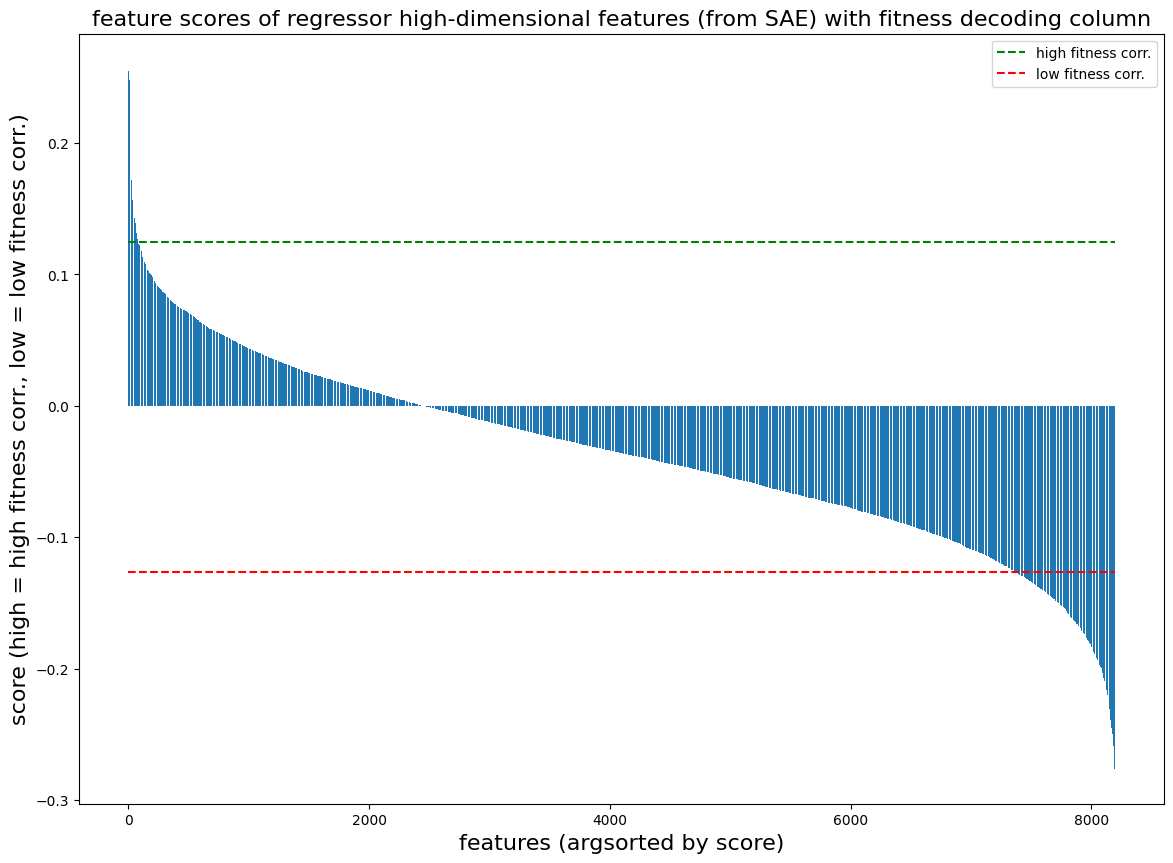

In [36]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.set_title("feature scores of regressor high-dimensional features (from SAE) with fitness decoding column", fontsize=16)
ax.bar(list(range(d_sae)), sae_feature_scores[sae_feature_score_sorted_indices])
ax.plot([0,d_sae], [sae_quantile_95, sae_quantile_95], color="green", label="high fitness corr.", linestyle="dashed")
ax.plot([0,d_sae], [sae_quantile_05, sae_quantile_05], color="red", label="low fitness corr.", linestyle="dashed")
ax.legend()

ax.set_xlabel("features (argsorted by score)", fontsize=16)
ax.set_ylabel("score (high = high fitness corr., low = low fitness corr.)", fontsize=16)
plt.show()

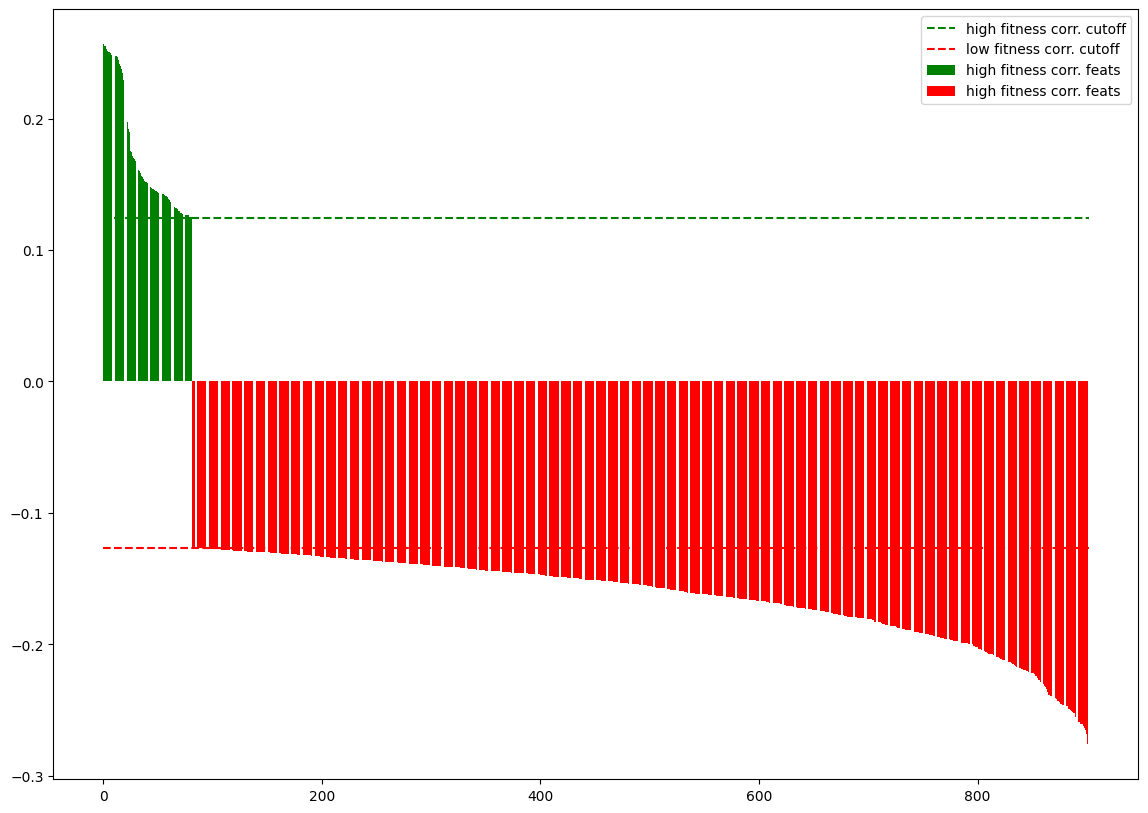

In [37]:
num_feats = high_fit_sae_feats.shape[0]+low_fit_sae_feats.shape[0]
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.bar(list(range(high_fit_sae_feats.shape[0])), sae_feature_scores[high_fit_sae_feats], color="green", label="high fitness corr. feats")
ax.bar(list(range(high_fit_sae_feats.shape[0], num_feats)), sae_feature_scores[low_fit_sae_feats], color="red", label="high fitness corr. feats")
ax.plot([0,num_feats], [sae_quantile_95, sae_quantile_95], color="green", label="high fitness corr. cutoff", linestyle="dashed")
ax.plot([0,num_feats], [sae_quantile_05, sae_quantile_05], color="red", label="low fitness corr. cutoff", linestyle="dashed")
ax.legend()
plt.show()

# Examining coefficients $f_j(x_i)$ of each argsorted features $d_j$ shown above

### Ideally, the coefficients $f_j(x_i^{\text{HIGH fit}})$ of the high-fitness seq. should be large on the features corr. w/ high fitness. Similarly, the coefficients $f_j(x_i^{\text{LOW fit}})$ of the low-fitness seq. should be large on the features corr. w/ low fitness (this is the 2nd row)
### Further, the high-fitness coefficients should NOT be active on the low-fit features and vice versa (this is the 3rd row)

In [38]:
high_fitness_acts = sae_data_activations[high_fitness_dset_indices, :]
low_fitness_acts = sae_data_activations[low_fitness_dset_indices, :]

In [39]:
_, _, high_fitness_sae_coefs, high_fit_recon = jumprelu_sae.forward(high_fitness_acts[:, None, :] * MAGNIFICATION_SIZE) #[batch, 1, d_sae], 1 for the n_inst which will be removed
_, _, low_fitness_sae_coefs, low_fit_recon = jumprelu_sae.forward(low_fitness_acts[:, None, :] * MAGNIFICATION_SIZE) #[batch, 1, d_sae], 1 for the n_inst which will be removed

mean_high_fit_sae_coefs = high_fitness_sae_coefs.mean(dim=0)[0].detach().cpu().numpy() / MAGNIFICATION_SIZE
mean_low_fit_sae_coefs = low_fitness_sae_coefs.mean(dim=0)[0].detach().cpu().numpy() / MAGNIFICATION_SIZE

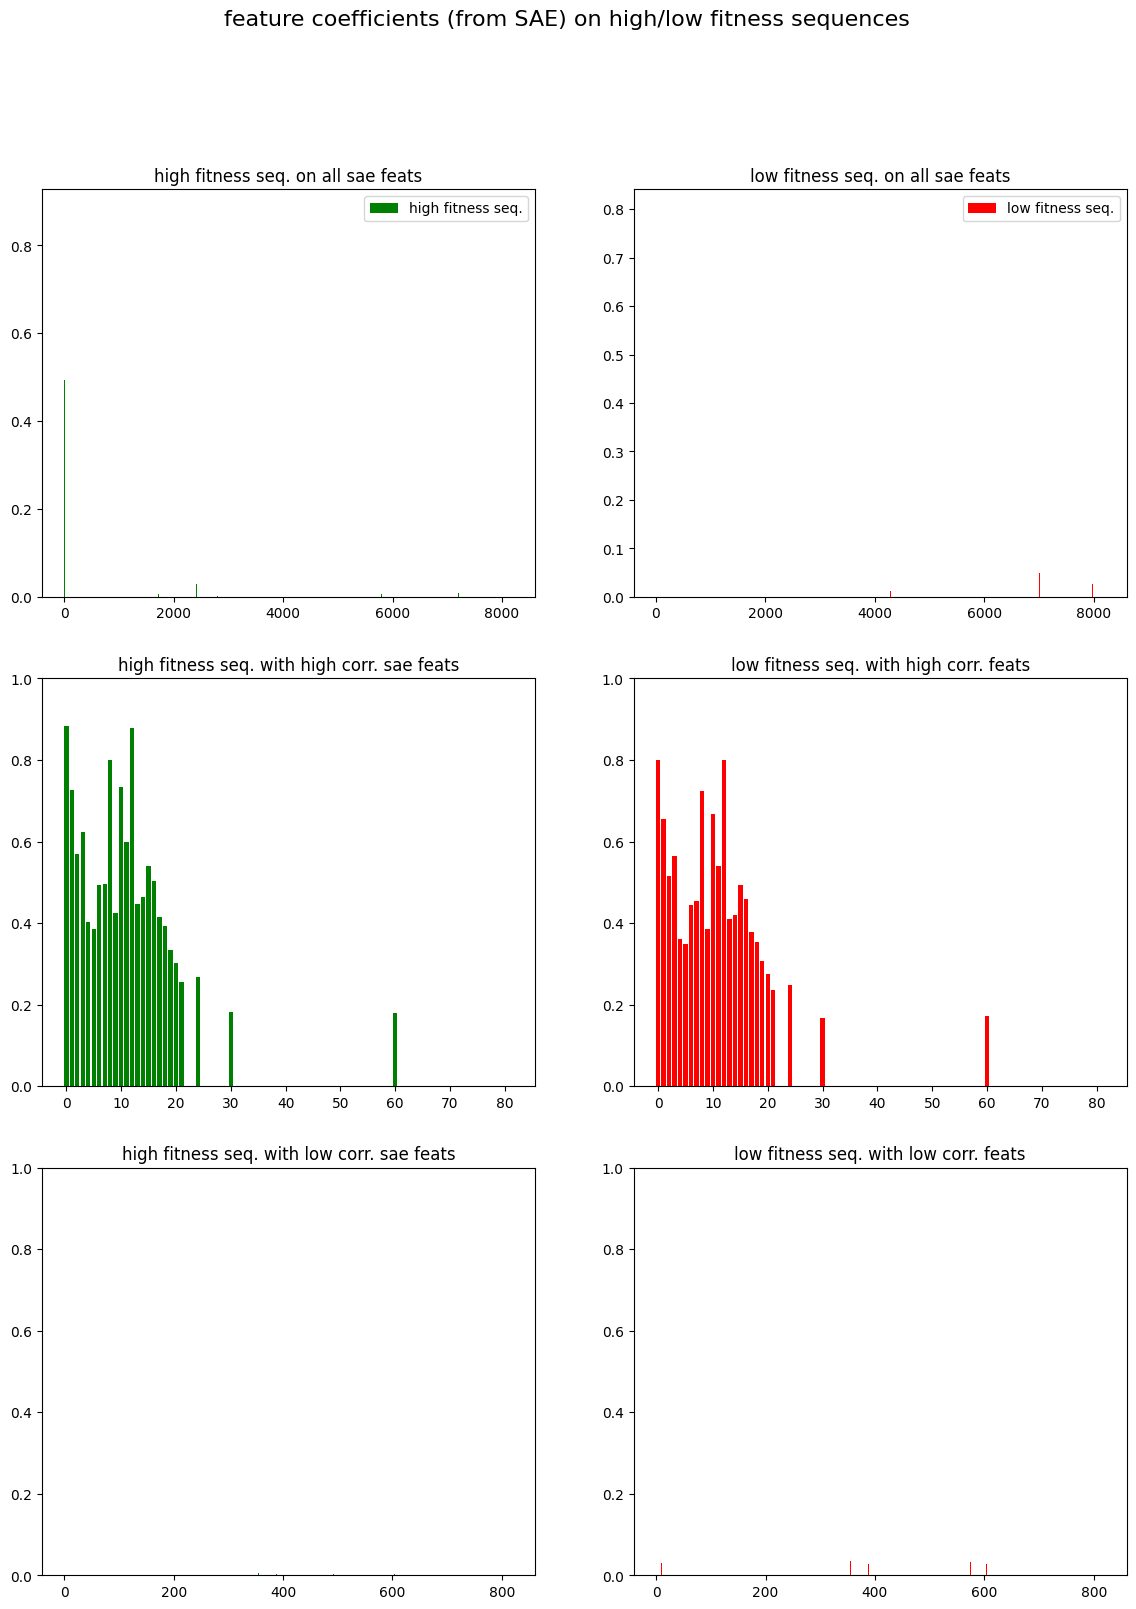

In [40]:
fig, ax = plt.subplots(3,2,figsize=(14,18))
fig.suptitle("feature coefficients (from SAE) on high/low fitness sequences", fontsize=16)
ax[0,0].bar(list(range(d_sae)), mean_high_fit_sae_coefs[sae_feature_score_sorted_indices], color="green", label="high fitness seq.", linewidth=10)
ax[0,1].bar(list(range(d_sae)), mean_low_fit_sae_coefs[sae_feature_score_sorted_indices], color="red", label="low fitness seq.", linewidth=10)

ax[1,0].bar(list(range(high_fit_sae_feats.shape[0])), mean_high_fit_sae_coefs[high_fit_sae_feats], color="green", label="high fitness seq.")
ax[1,0].set_ylim((0,1))
ax[1,1].bar(list(range(high_fit_sae_feats.shape[0])), mean_low_fit_sae_coefs[high_fit_sae_feats], color="red", label="low fitness seq.")
ax[1,1].set_ylim((0,1))

ax[2,0].bar(list(range(low_fit_sae_feats.shape[0])), mean_high_fit_sae_coefs[low_fit_sae_feats], color="green", label="high fitness seq.")
ax[2,0].set_ylim((0,1))
ax[2,1].bar(list(range(low_fit_sae_feats.shape[0])), mean_low_fit_sae_coefs[low_fit_sae_feats], color="red", label="low fitness seq.")
ax[2,1].set_ylim((0,1))


ax[0,0].legend()
ax[0,0].set_title("high fitness seq. on all sae feats")

ax[0,1].legend()
ax[0,1].set_title("low fitness seq. on all sae feats")

ax[1,0].set_title("high fitness seq. with high corr. sae feats")

ax[1,1].set_title("low fitness seq. with high corr. feats")

ax[2,0].set_title("high fitness seq. with low corr. sae feats")

ax[2,1].set_title("low fitness seq. with low corr. feats")

plt.show()

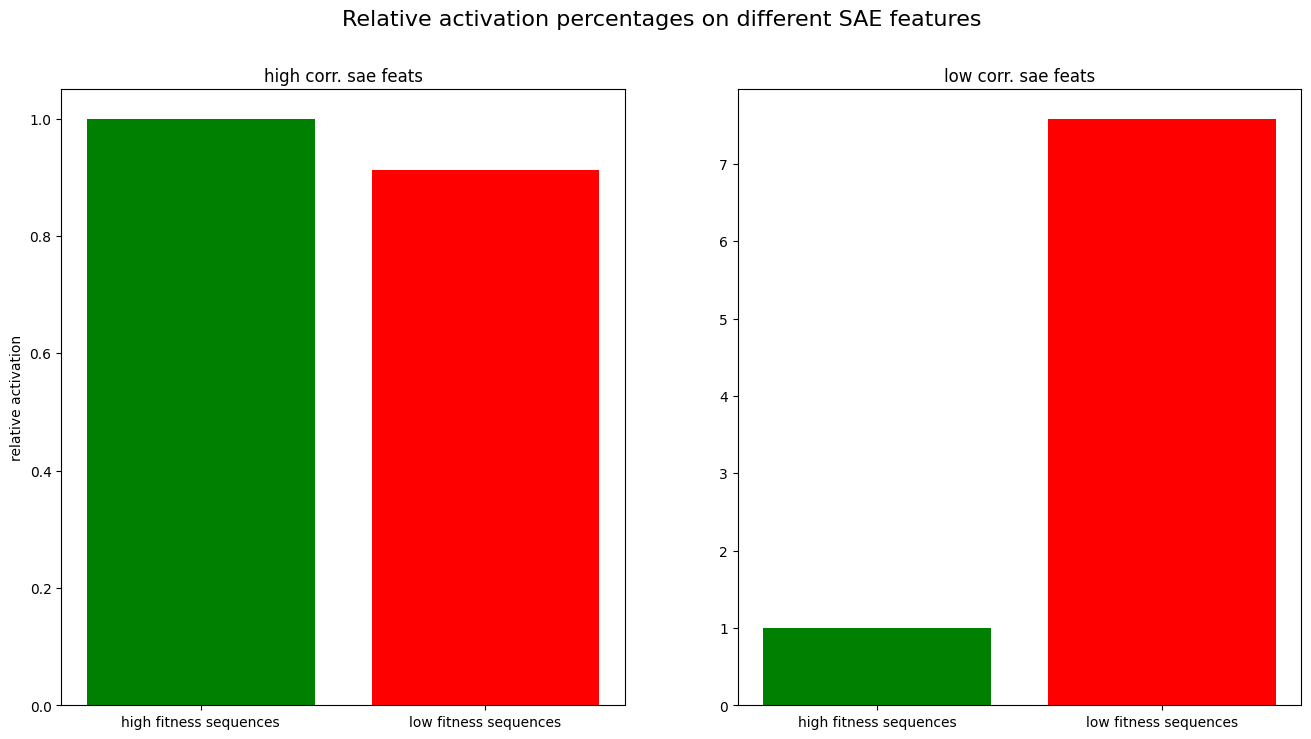

In [41]:
high_corr_non_zero_ind = mean_high_fit_sae_coefs[high_fit_sae_feats] > 0
high_corr_percentage = (mean_low_fit_sae_coefs[high_fit_sae_feats][high_corr_non_zero_ind] / mean_high_fit_sae_coefs[high_fit_sae_feats][high_corr_non_zero_ind]).mean()

low_corr_non_zero_ind = mean_high_fit_sae_coefs[low_fit_sae_feats] > 0
low_corr_percentage = (mean_low_fit_sae_coefs[low_fit_sae_feats][low_corr_non_zero_ind] / mean_high_fit_sae_coefs[low_fit_sae_feats][low_corr_non_zero_ind]).mean()
fig, ax = plt.subplots(1,2,figsize=(16,8))
fig.suptitle("Relative activation percentages on different SAE features", fontsize=16) 
ax[0].set_title("high corr. sae feats")
ax[0].bar([0],[1],color="green", label="high fitness seq.")
ax[0].bar([1],[high_corr_percentage], color="red", label="low fitness seq.")
ax[0].set_ylabel("relative activation")
ax[0].set_xticks([0,1], ["high fitness sequences", "low fitness sequences"])

ax[1].set_title("low corr. sae feats")
ax[1].bar([0],[1],color="green", label="high fitness seq.")
ax[1].bar([1],[low_corr_percentage], color="red", label="low fitness seq.")
ax[1].set_xticks([0,1], ["high fitness sequences", "low fitness sequences"])

plt.show()

# Finding which features head 32.8 affects the most

In [44]:
resid_component_names = ["blocks.0.hook_resid_pre"]
for layer in range(hooked_esm.cfg.n_layers):
    resid_mid_name = f"blocks.{layer}.hook_resid_mid"
    resid_post_name = f"blocks.{layer}.hook_resid_post"
    resid_component_names.append(resid_mid_name)
    resid_component_names.append(resid_post_name)

In [50]:
_, high_fit_cache = hooked_esm.run_with_cache(high_toks, names_filter=resid_component_names)
torch.cuda.empty_cache()

In [118]:
hooked_final_ln = hooked_esm.ln_final
L32_resid_name = resid_component_names[-2]
L32_acts = esm_fine_tuned.regressor[1](esm_fine_tuned.regressor[0](hooked_final_ln(high_fit_cache[L32_resid_name][:,0,:])))
_, _, L32H8_sae_coefs, L32H8_sae_recon = jumprelu_sae.forward(L32_acts[:, None, :] * MAGNIFICATION_SIZE)
L32H8_sae_coefs = (L32H8_sae_coefs[:,0,:].mean(dim=0) / MAGNIFICATION_SIZE).detach().cpu().numpy() 

high_fit_non_zero_ind = mean_high_fit_sae_coefs[high_fit_sae_feats] > 0
high_feat_rel_diffs = L32H8_sae_coefs[high_fit_sae_feats][high_fit_non_zero_ind] / mean_high_fit_sae_coefs[high_fit_sae_feats][high_fit_non_zero_ind]
L32_boosted_inds = np.argwhere(high_fit_non_zero_ind)[:,0][high_feat_rel_diffs > 1]

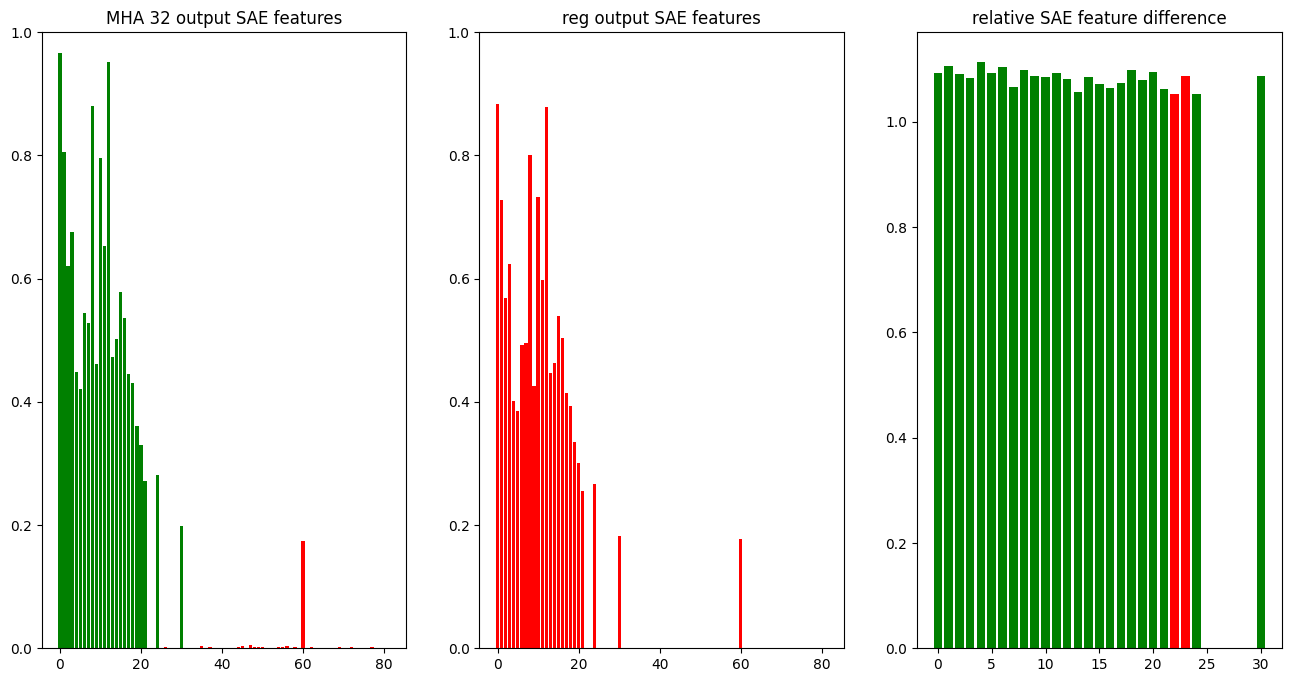

In [119]:
fig, ax = plt.subplots(1,3,figsize=(16,8))
ax[0].bar(list(range(high_fit_sae_feats.shape[0])), L32H8_sae_coefs[high_fit_sae_feats], color="red")
ax[0].bar(L32_boosted_inds, L32H8_sae_coefs[high_fit_sae_feats][L32_boosted_inds], color="green")
ax[0].set_ylim((0,1))
ax[0].set_title("MHA 32 output SAE features")

ax[1].bar(list(range(high_fit_sae_feats.shape[0])), mean_high_fit_sae_coefs[high_fit_sae_feats], color="red")
ax[1].set_ylim((0,1))
ax[1].set_title("reg output SAE features")

ax[2].bar(list(range(high_feat_rel_diffs.shape[0])), high_feat_rel_diffs, color="red")
ax[2].bar(L32_boosted_inds, high_feat_rel_diffs[high_feat_rel_diffs > 1], color="green")
ax[2].set_title("relative SAE feature difference")
plt.show()

In [175]:
def plot_useful_idx_over_layer(useful_idx, **kwargs):
    sae_feats_over_layes = np.zeros((len(resid_component_names), useful_idx.shape[0]))
    hooked_final_ln = hooked_esm.ln_final
    for i, resid_name in enumerate(resid_component_names):
        
        resid_acts = esm_fine_tuned.regressor[1](esm_fine_tuned.regressor[0](hooked_final_ln(high_fit_cache[resid_name][:,0,:]))) # [batch, 256]
        _, _, resid_sae_coefs, _ = jumprelu_sae.forward(resid_acts[:, None, :] * MAGNIFICATION_SIZE) # [batch 1 d_sae], 1 is for n_inst
        
        resid_sae_coefs = (resid_sae_coefs[:,0,:].mean(dim=0) / MAGNIFICATION_SIZE).detach().cpu().numpy() # [d_sae]
        resid_sae_coefs_high_corr = resid_sae_coefs[useful_idx] # [useful_idx.shape[0]]
        sae_feats_over_layes[i,:] = resid_sae_coefs_high_corr

    df = pd.DataFrame(
        {
            "sae_feat": [i for i in range(sae_feats_over_layes.shape[1]) for _ in range(len(resid_component_names))],
            "component": [i for _ in range(sae_feats_over_layes.shape[1]) for i in range(len(resid_component_names))],
            "sae_coef": [sae_feats_over_layes[j, i] for i in range(sae_feats_over_layes.shape[1]) for j in range(len(resid_component_names))]
        }
    )
    fig = px.line(df, x="component", y="sae_coef", color="sae_feat", **kwargs)
    fig.update_layout(
        xaxis = dict(
            tickmode = 'array',
            tickvals = [i for i in range(len(resid_component_names))],
            ticktext = resid_component_names
        )
    )
    fig.show()

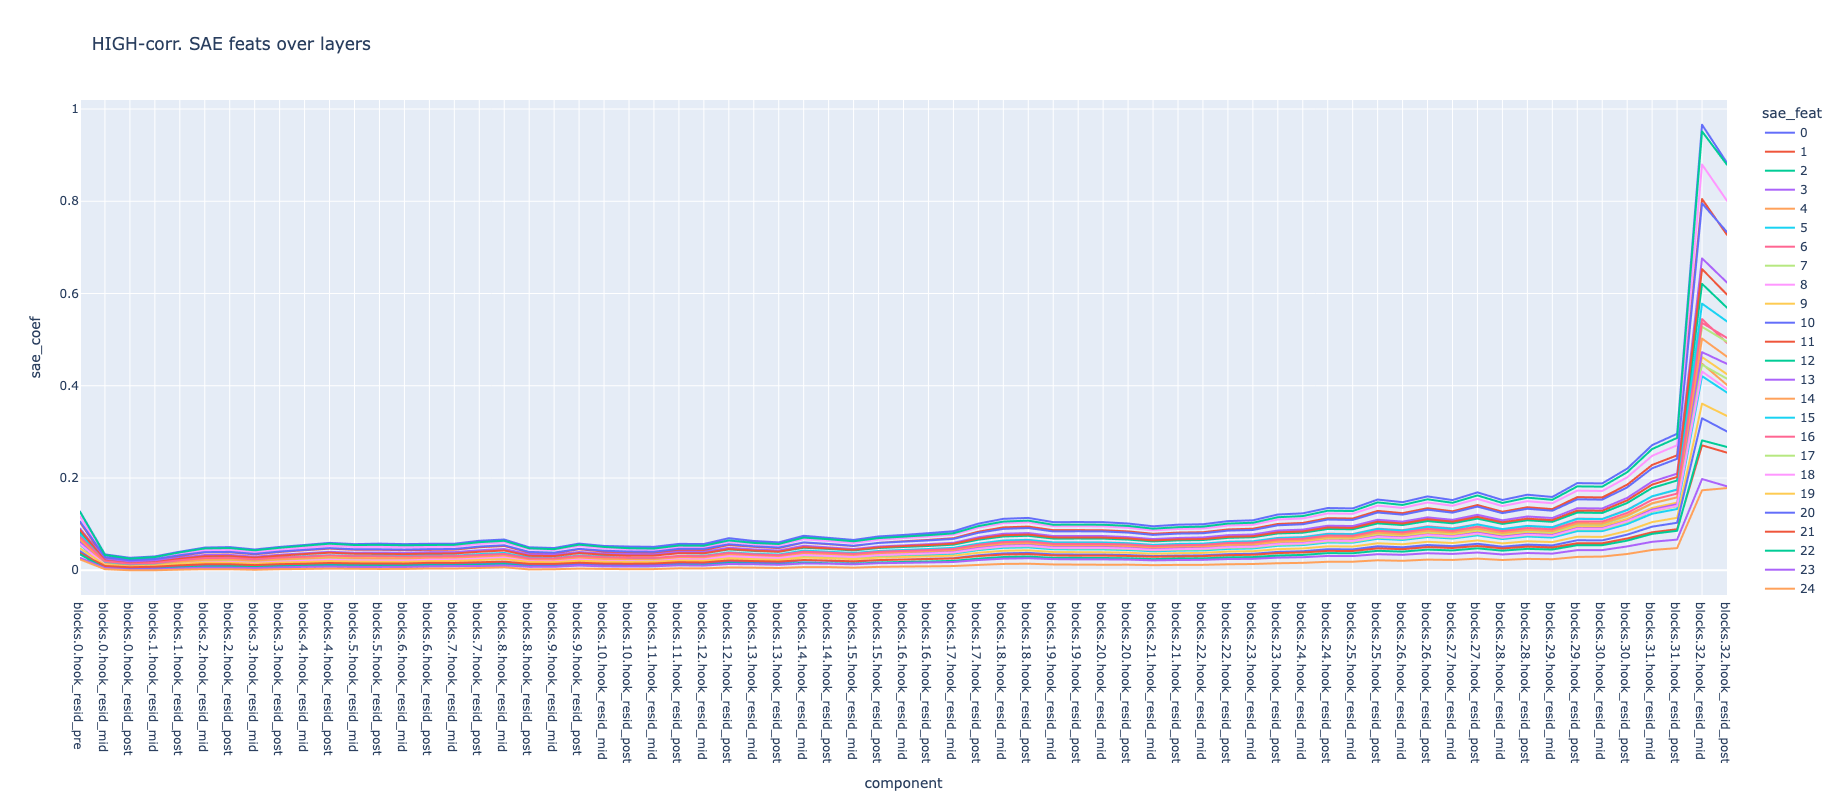

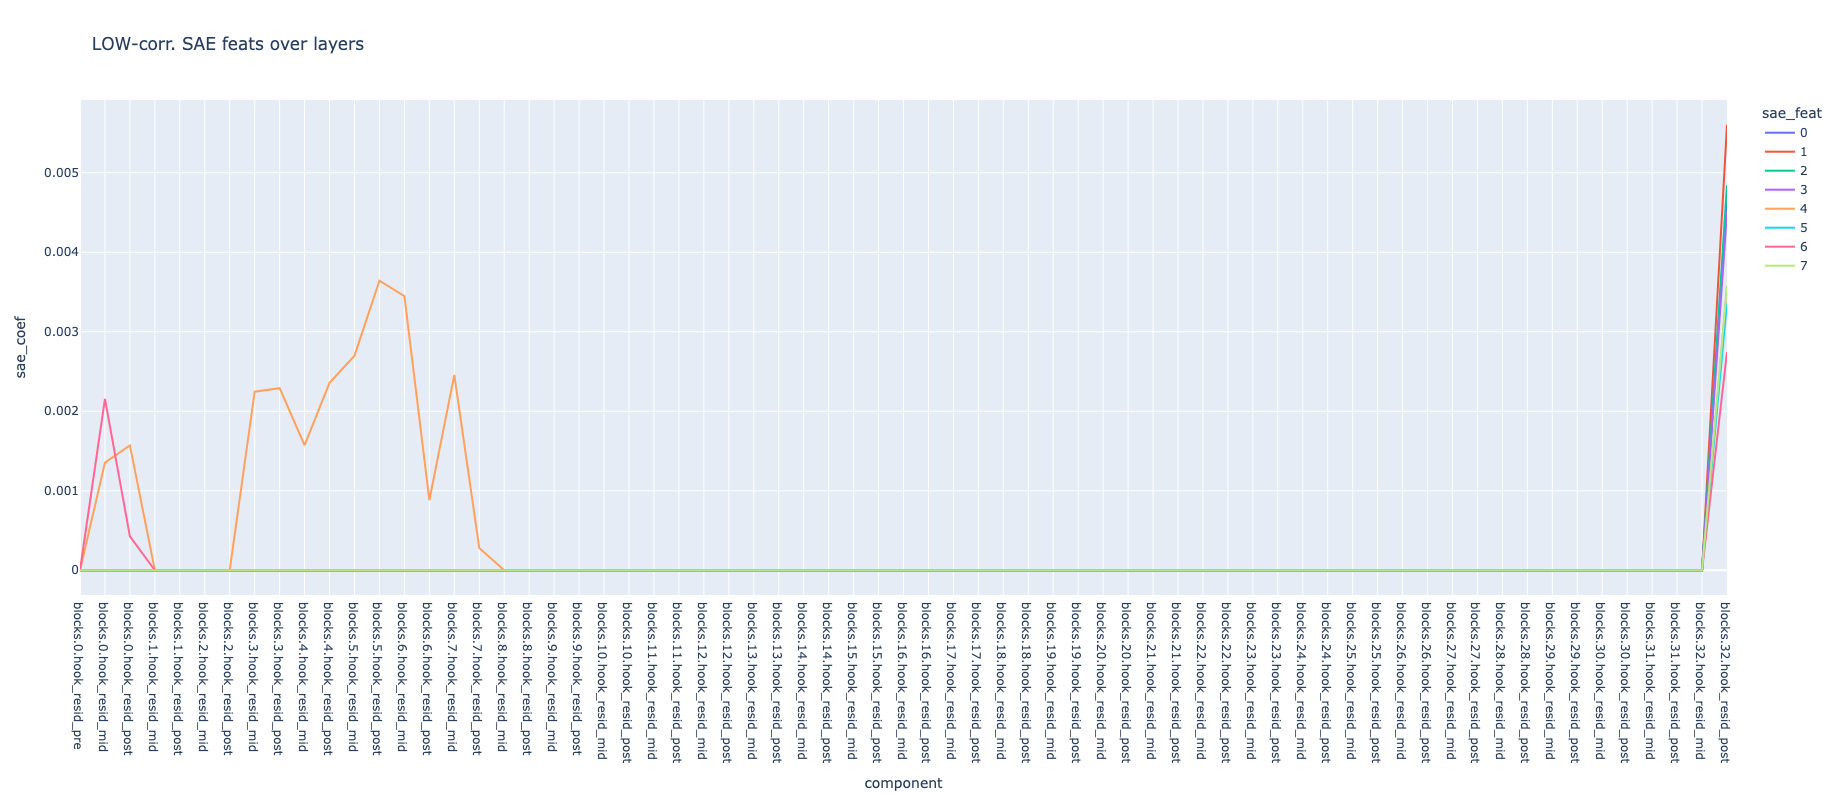

In [183]:
high_corr_non_zero_ind = mean_high_fit_sae_coefs[high_fit_sae_feats] > 0
low_corr_non_zero_ind = mean_high_fit_sae_coefs[low_fit_sae_feats] > 0

plot_useful_idx_over_layer(
    useful_idx=high_fit_sae_feats[np.argwhere(high_corr_non_zero_ind)[:,0]], 
    title="HIGH-corr. SAE feats over layers",
    width=1400,
    height=800
)
plot_useful_idx_over_layer(
    useful_idx=low_fit_sae_feats[np.argwhere(low_corr_non_zero_ind)[:,0]], 
    title="LOW-corr. SAE feats over layers",
    width=1400,
    height=800
)